# Пример загрузки baseline модели получение mIoU на валидационном датасете

## Хедеры и константы

In [10]:
import zipfile
from pathlib import Path
from urllib.request import urlretrieve
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import torch
import segmentation_models_pytorch as smp
from tqdm.auto import tqdm
from pycocotools.coco import COCO
import numpy as np
from PIL import Image as PILImage
from torchvision.transforms import v2 as tr
from torch.utils.data import DataLoader, Dataset
from torchvision import tv_tensors

import colorsys
from torchvision.transforms import InterpolationMode
from torchvision.transforms.functional import pil_to_tensor

In [11]:
ROOT_DATASET = "./dataset_coco"
CKPT_PATH = "./weights/checkpoint_coco_fp16.pt"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IGNORE_INDEX = 255

NUM_CLASSES = 81
IMAGE_SIZE = (384, 384)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

NUM_WORKERS = 4
BATCH_SIZE = 16

## Загрузка модели

In [12]:
model = smp.Unet(
    encoder_name="resnet101",
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,
)

baseline = model.half() # fp16
# baseline = model.bfloat16() # bf16

state = torch.load(CKPT_PATH, map_location="cpu")
baseline.load_state_dict(state, strict=True)

baseline = baseline.to(DEVICE).eval()

## Формирование датасета

In [13]:
class SegTransform:
    '''
    Класс-преобразователь, который применяет аугментации к паре (image, mask)
    '''
    
    def __init__(self, size, train=True):

        self.mean = IMAGENET_MEAN
        self.std = IMAGENET_STD

        if train:
            self.joint_prepare = tr.Compose([
                tr.RandomResizedCrop(
                    size,
                    scale=(0.6, 1.0),
                    interpolation=InterpolationMode.BILINEAR,
                    antialias=True
                ),
                tr.RandomHorizontalFlip(p=0.5),
            ])
        else:
            self.joint_prepare = tr.Compose([
                tr.Resize(size, interpolation=InterpolationMode.BILINEAR, antialias=True),
            ])

        if train:
            self.image_prepare = tr.Compose([
                tr.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
                tr.ToDtype(torch.float32, scale=True),
                tr.Normalize(mean=self.mean, std=self.std),
            ])
        else:
            self.image_prepare = tr.Compose([
                tr.ToDtype(torch.float32, scale=True),
                tr.Normalize(mean=self.mean, std=self.std),
            ])

    def __call__(self, image, mask):
        image = tv_tensors.Image(image)
        mask = tv_tensors.Mask(pil_to_tensor(mask).squeeze(0).to(torch.int64))  # без np.array

        image, mask = self.joint_prepare(image, mask)
        image = self.image_prepare(image)
        return image, mask.long()

In [14]:
class COCOSemanticDataset(Dataset):
    """
    Semantic-seg dataset на базе COCO instances.
    Возвращает:
      image: PIL.Image (RGB)
      mask:  PIL.Image (L), где:
             0 = background
             1..N = категории COCO (плотная перенумерация)
             ignore_index (по умолчанию 255) можно использовать при необходимости
    """

    def __init__(
        self,
        root=ROOT_DATASET,
        split="train2017",
        masks_root="semantic_masks",
        ann_file=None,
        transforms=None,
        ignore_index=IGNORE_INDEX,
    ):
        self.root = Path(root)
        self.split = split
        self.transforms = transforms
        self.ignore_index = ignore_index

        self.images_dir = self.root / split
        self.masks_dir = self.root / masks_root / split

        if ann_file is None:
            ann_file = self.root / "annotations" / f"instances_{split}.json"
        self.coco = COCO(str(ann_file))

        self.image_ids = sorted(self.coco.getImgIds())

        cat_ids = sorted(self.coco.getCatIds())
        cats = self.coco.loadCats(cat_ids)
        self.class_names = ["background"] + [c["name"] for c in sorted(cats, key=lambda x: x["id"])]
        self.num_classes = len(self.class_names)

        # Проверка наличия масок
        missing = 0
        for image_id in self.image_ids[:500]:  # быстрая проверка части
            info = self.coco.loadImgs(image_id)[0]
            mpath = self.masks_dir / (Path(info["file_name"]).stem + ".png")
            if not mpath.exists():
                missing += 1
        if missing > 0:
            raise FileNotFoundError(
                f"Missing precomputed masks in {self.masks_dir}. "
                f"Run build_coco_semantic_masks(...) first."
            )

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        info = self.coco.loadImgs(image_id)[0]

        image_path = self.images_dir / info["file_name"]
        mask_path = self.masks_dir / (Path(info["file_name"]).stem + ".png")

        with PILImage.open(image_path) as im:
            image = im.convert("RGB").copy()

        with PILImage.open(mask_path) as mm:
            mask = mm.convert("L").copy()

        if self.transforms is not None:
            image, mask = self.transforms(image, mask)

        return image, mask

In [15]:
val_ds = COCOSemanticDataset(
    root=ROOT_DATASET,
    split="val2017",
    masks_root="semantic_masks",
    transforms=SegTransform(size=IMAGE_SIZE, train=False),
)

loading annotations into memory...
Done (t=0.67s)
creating index...
index created!


In [16]:
def seg_collate_fn(batch):
    images, masks = zip(*batch)
    images = torch.stack(images, dim=0)
    masks = torch.stack(masks, dim=0)
    return images, masks

In [17]:
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=2,
    collate_fn=seg_collate_fn,
    timeout= 60,
)

## Получение примеров предсказаний

In [18]:
def _build_seg_cmap_with_ignore(num_classes: int, ignore_color=(0.15, 0.15, 0.15, 1.0)):
    hues = (np.arange(num_classes) * 0.61803398875) % 1.0
    colors = []
    for h in hues:
        r, g, b = colorsys.hsv_to_rgb(h, 0.75, 1.0)
        colors.append((r, g, b, 1.0))

    colors.append(ignore_color)
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, num_classes + 1.5, 1), cmap.N)
    return cmap, norm

def _mask_boundaries(m: np.ndarray) -> np.ndarray:
    b = np.zeros_like(m, dtype=bool)
    b[:-1, :] |= (m[:-1, :] != m[1:, :])
    b[:, :-1] |= (m[:, :-1] != m[:, 1:])
    return b

def _boundary_rgba(mask: np.ndarray, color=(1.0, 1.0, 1.0, 1.0)):
    bd = _mask_boundaries(mask)
    overlay = np.zeros((*bd.shape, 4), dtype=np.float32)
    overlay[bd] = color
    return overlay

def show_val_predictions_triplets(
    model,
    val_ds,
    device,
    n_samples: int = 4,
    seed: int = 42,
    ignore_index: int = IGNORE_INDEX,
    max_legend_classes: int = 10,
):
    model.eval()
    rng = random.Random(seed)
    idxs = [rng.randrange(len(val_ds)) for _ in range(n_samples)]

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    num_classes = val_ds.num_classes
    ignore_show_id = num_classes
    cmap, norm = _build_seg_cmap_with_ignore(num_classes)

    fig, axes = plt.subplots(
        n_samples, 4, figsize=(16, 4 * n_samples),
        gridspec_kw={"width_ratios": [1, 1, 1, 0.9]}
    )
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    param_dtype = next(model.parameters()).dtype

    with torch.no_grad():
        for i, idx in enumerate(idxs):
            image, true_mask = val_ds[idx]
            x = image.unsqueeze(0).to(device, non_blocking=True)

            if param_dtype in (torch.float16, torch.bfloat16):
                x = x.to(dtype=param_dtype)

            logits = model(x)
            pred_mask = logits.argmax(dim=1).squeeze(0).cpu().numpy()

            img_show = (image.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
            true_show = true_mask.cpu().numpy().copy()
            true_show[true_show == ignore_index] = ignore_show_id

            axes[i, 0].imshow(img_show)
            axes[i, 0].set_title(f"image #{idx}")
            axes[i, 0].axis("off")

            axes[i, 1].imshow(true_show, cmap=cmap, norm=norm, interpolation="nearest")
            axes[i, 1].imshow(_boundary_rgba(true_show), interpolation="nearest")
            axes[i, 1].set_title("true_mask_val")
            axes[i, 1].axis("off")

            axes[i, 2].imshow(pred_mask, cmap=cmap, norm=norm, interpolation="nearest")
            axes[i, 2].imshow(_boundary_rgba(pred_mask), interpolation="nearest")
            axes[i, 2].set_title("pred_mask")
            axes[i, 2].axis("off")

            # Легенда только по классам этой тройки
            ids, counts = np.unique(np.concatenate([true_show.ravel(), pred_mask.ravel()]), return_counts=True)
            order = np.argsort(-counts)
            ids = ids[order]

            shown = ids[:max_legend_classes]
            handles = []
            for cid in shown:
                cid = int(cid)
                if cid == ignore_show_id:
                    label = "255: ignore"
                else:
                    label = f"{cid}: {val_ds.class_names[cid]}"
                handles.append(Patch(facecolor=cmap(cid), edgecolor="none", label=label))                

            axes[i, 3].axis("off")
            axes[i, 3].legend(handles=handles, loc="upper left", frameon=False, fontsize=8, handlelength=1.0)
            extra = len(ids) - len(shown)
            axes[i, 3].set_title(f"classes in sample{f' (+{extra} more)' if extra > 0 else ''}", fontsize=9)

    plt.tight_layout()
    plt.show()


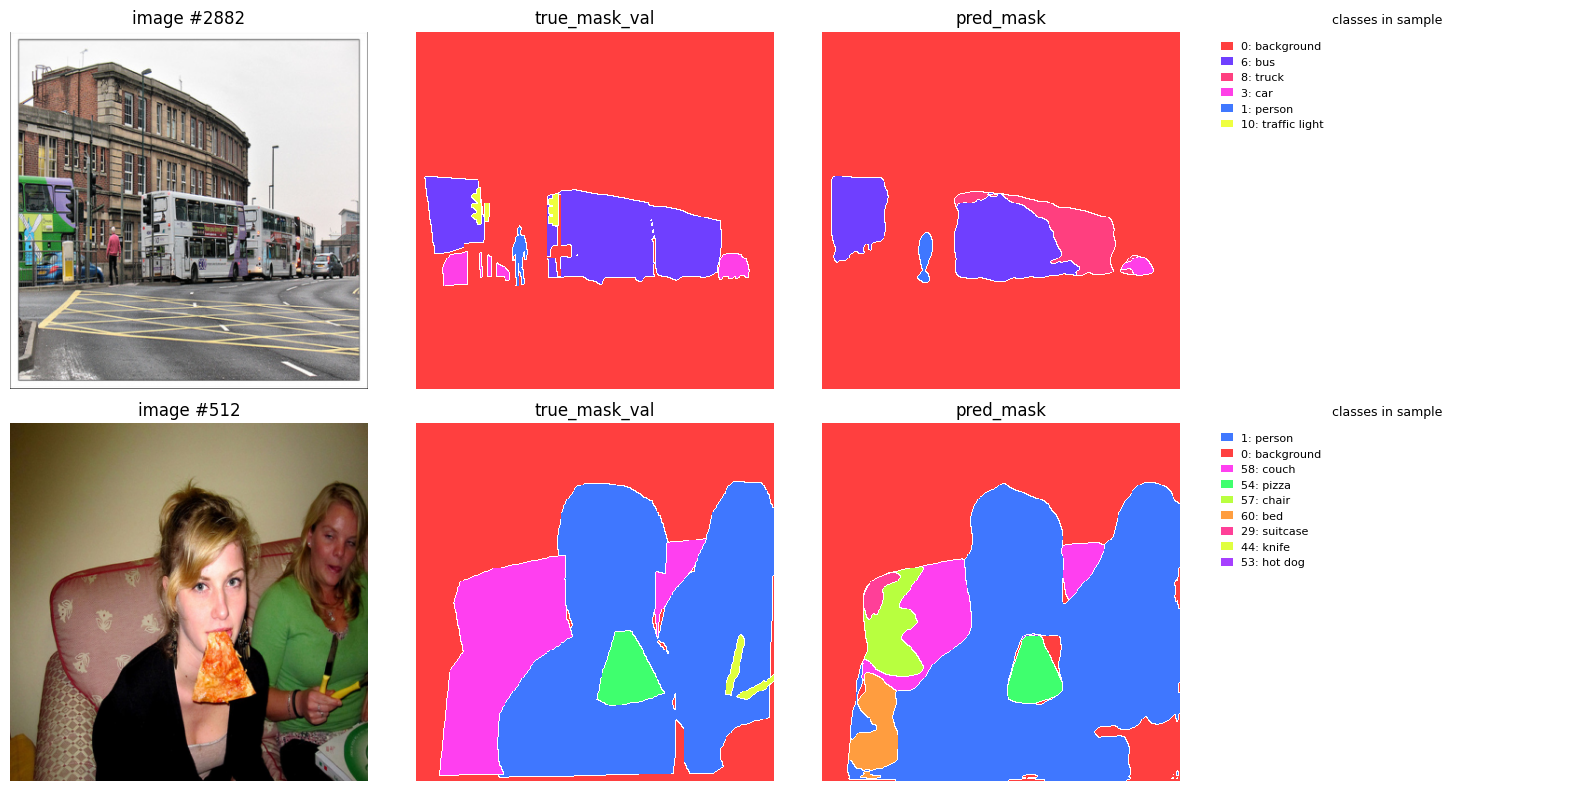

In [19]:
show_val_predictions_triplets(
    model=model,
    val_ds=val_ds,
    device=DEVICE,
    n_samples=2,
    seed=47,
    ignore_index=IGNORE_INDEX,
)

## Получение метрик 

In [20]:
@torch.no_grad()
def per_class_iou(
    model,
    loader,
    device,
    class_names,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    ):
    model.eval()
    confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64, device=device)

    param_dtype = next(model.parameters()).dtype

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).long()

        if param_dtype in (torch.float16, torch.bfloat16):
            images = images.to(dtype=param_dtype)
        # if is_half_model:
        #     images = images.half()

        logits = model(images)
        preds = logits.argmax(dim=1)

        valid = masks != ignore_index
        t = masks[valid]
        p = preds[valid]
        if t.numel() == 0:
            continue

        idx = t * num_classes + p
        confmat += torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)

    tp = confmat.diag()
    fp = confmat.sum(0) - tp
    fn = confmat.sum(1) - tp
    denom = tp + fp + fn

    iou = tp.float() / torch.clamp(denom.float(), min=1.0)
    present = denom > 0
    miou_present = iou[present].mean().item()

    rows = []
    for i in range(num_classes):
        rows.append({
            "class_id": i,
            "class_name": class_names[i],
            "iou": float(iou[i].item()),
            "present_in_val": bool(present[i].item()),
            "pixels_gt_or_pred": int(denom[i].item()),
        })

    return rows, miou_present

In [21]:
rows, miou_present = per_class_iou(baseline, val_loader, DEVICE, val_ds.class_names, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX)
print("mIoU (only present classes):", round(miou_present, 4))

for r in rows:
    print(f"{r['class_id']:2d} {r['class_name']:12s} IoU={r['iou']:.3f} present={r['present_in_val']}")


mIoU (only present classes): 0.4525
 0 background   IoU=0.874 present=True
 1 person       IoU=0.769 present=True
 2 bicycle      IoU=0.516 present=True
 3 car          IoU=0.451 present=True
 4 motorcycle   IoU=0.681 present=True
 5 airplane     IoU=0.640 present=True
 6 bus          IoU=0.639 present=True
 7 train        IoU=0.635 present=True
 8 truck        IoU=0.376 present=True
 9 boat         IoU=0.420 present=True
10 traffic light IoU=0.488 present=True
11 fire hydrant IoU=0.738 present=True
12 stop sign    IoU=0.823 present=True
13 parking meter IoU=0.641 present=True
14 bench        IoU=0.336 present=True
15 bird         IoU=0.689 present=True
16 cat          IoU=0.766 present=True
17 dog          IoU=0.664 present=True
18 horse        IoU=0.609 present=True
19 sheep        IoU=0.644 present=True
20 cow          IoU=0.607 present=True
21 elephant     IoU=0.814 present=True
22 bear         IoU=0.808 present=True
23 zebra        IoU=0.864 present=True
24 giraffe      IoU=0.773 

# **torch.compile Experiment**

In [22]:
import json
import time
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp

In [23]:
DEVICE_STR = "cuda" if torch.cuda.is_available() else "cpu"

CKPT_PATH = "./weights/checkpoint_coco_fp16.pt"
MODEL_PATH = CKPT_PATH
NUM_CLASSES_EXP = NUM_CLASSES if "NUM_CLASSES" in globals() else 81
IGNORE_INDEX_EXP = IGNORE_INDEX if "IGNORE_INDEX" in globals() else 255
INPUT_SIZE_EXP = IMAGE_SIZE if "IMAGE_SIZE" in globals() else (384, 384)

MODEL_DTYPE = torch.float16

# гиперпараметры benchmark
WARMUP = 10
ITERS = 30
BENCH_BATCH_SIZE = val_loader.batch_size


COMPILE_CONFIGS = {
    "pytorch_baseline": None,
    "torch_compile_default": {
        "backend": "inductor",
        "mode": "default",
        "dynamic": False,
    },
    "torch_compile_tuned": {
        "backend": "inductor",
        "mode": "max-autotune",
        "dynamic": False,
    },
}


## model initialization

In [24]:
def get_model_param_dtype(model):
    return next(model.parameters()).dtype


def cast_tensor_to_model_dtype(x, model):
    dtype = get_model_param_dtype(model)
    if dtype in (torch.float16, torch.bfloat16, torch.float32):
        return x.to(dtype=dtype)
    return x


def build_model_and_load_ckpt(path=MODEL_PATH, dtype=MODEL_DTYPE, device=DEVICE_STR):
    model = smp.Unet(
        encoder_name="resnet101",
        encoder_weights=None,
        in_channels=3,
        classes=NUM_CLASSES_EXP,
        activation=None,
    )

    state = torch.load(path, map_location="cpu")
    if "model_state_dict" in state:
        state = state["model_state_dict"]
    elif "state_dict" in state:
        state = state["state_dict"]

    model.load_state_dict(state, strict=True)
    model = model.to(dtype=dtype).to(device).eval()

    print("Loaded model dtype:", next(model.parameters()).dtype)
    return model


## Loader для torch.compile

In [25]:
def make_compile_eval_loader(base_loader):
    kwargs = dict(
        dataset=base_loader.dataset,
        batch_size=base_loader.batch_size,
        shuffle=False,
        num_workers=base_loader.num_workers,
        pin_memory=getattr(base_loader, "pin_memory", False),
        collate_fn=base_loader.collate_fn,
        drop_last=True,
    )

    if hasattr(base_loader, "persistent_workers"):
        kwargs["persistent_workers"] = getattr(base_loader, "persistent_workers", False)

    if hasattr(base_loader, "prefetch_factor"):
        try:
            kwargs["prefetch_factor"] = getattr(base_loader, "prefetch_factor")
        except Exception:
            pass

    if hasattr(base_loader, "timeout"):
        kwargs["timeout"] = getattr(base_loader, "timeout", 0)

    return DataLoader(**kwargs)


## bencmark функции

In [26]:
def get_benchmark_input(loader, batch_size=1, device="cpu"):
    images, _ = next(iter(loader))
    x = images[:batch_size].contiguous()
    return x.to(device)


@torch.no_grad()
def warmup_model(model, x, device, warmup=WARMUP):
    model.eval()
    x_run = cast_tensor_to_model_dtype(x.to(device), model)

    for _ in range(warmup):
        _ = model(x_run)

    if device.startswith("cuda"):
        torch.cuda.synchronize()


@torch.no_grad()
def measure_first_run_compile_overhead(model, x, device):
    model.eval()
    x_run = cast_tensor_to_model_dtype(x.to(device), model)

    if device.startswith("cuda"):
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    _ = model(x_run)
    if device.startswith("cuda"):
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    return float(t1 - t0)


@torch.no_grad()
def benchmark_torch_model(model, x, device, warmup=WARMUP, iters=ITERS):
    model.eval()
    x_run = cast_tensor_to_model_dtype(x.to(device), model)

    # warmup
    for _ in range(warmup):
        _ = model(x_run)
    if device.startswith("cuda"):
        torch.cuda.synchronize()

    times = []
    for _ in range(iters):
        t0 = time.perf_counter()
        _ = model(x_run)
        if device.startswith("cuda"):
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000.0)

    times = np.array(times, dtype=np.float64)
    mean_ms = float(times.mean())

    return {
        "latency_ms": mean_ms,
        "p50_ms": float(np.percentile(times, 50)),
        "p95_ms": float(np.percentile(times, 95)),
        "throughput_img_s": float(x_run.shape[0] / (mean_ms / 1000.0)),
    }

@torch.no_grad()
def per_class_iou_compile(
    model,
    loader,
    device,
    num_classes=NUM_CLASSES_EXP,
    ignore_index=IGNORE_INDEX_EXP,
):
    model.eval()
    confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64, device=device)

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).long()

        images = cast_tensor_to_model_dtype(images, model)

        logits = model(images)
        preds = logits.argmax(dim=1)

        valid = masks != ignore_index
        t = masks[valid]
        p = preds[valid]
        if t.numel() == 0:
            continue

        idx = t * num_classes + p
        confmat += torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)

    tp = confmat.diag()
    fp = confmat.sum(0) - tp
    fn = confmat.sum(1) - tp
    denom = tp + fp + fn

    iou = tp.float() / torch.clamp(denom.float(), min=1.0)
    present = denom > 0
    miou_present = iou[present].mean().item()

    class_names = None
    if hasattr(loader.dataset, "class_names"):
        class_names = loader.dataset.class_names
    else:
        class_names = [str(i) for i in range(num_classes)]

    rows = []
    for i in range(num_classes):
        rows.append({
            "class_id": i,
            "class_name": class_names[i],
            "iou": float(iou[i].item()),
            "present_in_val": bool(present[i].item()),
            "pixels_gt_or_pred": int(denom[i].item()),
        })

    return rows, miou_present

## Главная функция эксперимента

In [27]:
def build_inference_method(method_name, base_model):
    if method_name == "pytorch_baseline":
        return deepcopy(base_model).eval()

    cfg = COMPILE_CONFIGS[method_name]
    model = deepcopy(base_model).eval()

    compiled = torch.compile(
        model,
        backend=cfg["backend"],
        mode=cfg["mode"],
        dynamic=cfg["dynamic"],
    )
    return compiled

In [28]:
def run_torch_compile_experiment(
    val_loader,
    model_loaded=None,
    checkpoint_path=MODEL_PATH,
    model_dtype=MODEL_DTYPE,
):
    """
    Возвращает:
    {
        "results": {...},
        "per_class_rows": {...},
    }
    """

    if model_loaded is None:
        model_loaded = build_model_and_load_ckpt(
            path=checkpoint_path,
            dtype=model_dtype,
            device=DEVICE_STR,
        )

    model_native = deepcopy(model_loaded).to(DEVICE_STR).eval()
    native_dtype = get_model_param_dtype(model_native)

    print("Native model dtype:", native_dtype)

    compile_loader = make_compile_eval_loader(val_loader)

    x_bench = get_benchmark_input(
        compile_loader,
        batch_size=compile_loader.batch_size,
        device=DEVICE_STR,
    )

    print("Benchmark input shape:", tuple(x_bench.shape))

    results = {}
    per_class_rows = {}


    for method_name in COMPILE_CONFIGS.keys():
        print(f"\n=== Running: {method_name} ===")

        model_method = build_inference_method(method_name, model_native)

        first_run_sec = measure_first_run_compile_overhead(
            model_method, x_bench, DEVICE_STR
        )

        bench = benchmark_torch_model(
            model_method,
            x_bench,
            DEVICE_STR,
            warmup=WARMUP,
            iters=ITERS,
        )

        rows, miou = per_class_iou_compile(
            model_method,
            compile_loader,
            DEVICE_STR,
            num_classes=NUM_CLASSES_EXP,
            ignore_index=IGNORE_INDEX_EXP,
        )

        results[method_name] = {
            **bench,
            "miou_present": float(miou),
            "dtype": str(native_dtype).replace("torch.", ""),
            "compile_wall_sec": float(first_run_sec),
        }
        per_class_rows[method_name] = rows

    print("\n=== RAW RESULTS ===")
    print(json.dumps(results, indent=2, ensure_ascii=False))

    return {
        "results": results,
        "per_class_rows": per_class_rows,
    }


## Функции отображения результатов

In [29]:
def show_torch_compile_report(exp_out, title="Отчет по сравнению torch.compile"):
    if isinstance(exp_out, dict) and "results" in exp_out:
        results = exp_out["results"]
    else:
        results = exp_out

    rows = []
    errors = []

    for method, vals in results.items():
        if not isinstance(vals, dict):
            errors.append({"method": method, "error": f"Unexpected value type: {type(vals)}"})
            continue

        if "error" in vals:
            errors.append({"method": method, "error": vals["error"]})
            continue

        required_keys = [
            "latency_ms",
            "p50_ms",
            "p95_ms",
            "throughput_img_s",
            "miou_present",
            "compile_wall_sec",
        ]
        missing = [k for k in required_keys if k not in vals]
        if missing:
            errors.append({"method": method, "error": f"Missing keys: {missing}"})
            continue

        rows.append({
            "method": method,
            "latency_ms": float(vals["latency_ms"]),
            "p50_ms": float(vals["p50_ms"]),
            "p95_ms": float(vals["p95_ms"]),
            "throughput_img_s": float(vals["throughput_img_s"]),
            "miou_present": float(vals["miou_present"]),
            "miou_percent": float(vals["miou_present"]) * 100.0,
            "compile_wall_sec": float(vals["compile_wall_sec"]),
            "dtype": vals.get("dtype", ""),
        })

    df = pd.DataFrame(rows)
    err_df = pd.DataFrame(errors)

    if df.empty:
        print("Нет валидных результатов.")
        if not err_df.empty:
            display(err_df)
        return df, err_df

    method_order = [
        "pytorch_baseline",
        "torch_compile_default",
        "torch_compile_tuned",
    ]

    pretty_names_ru = {
        "pytorch_baseline": "Оригинальная\n(PyTorch eager)",
        "torch_compile_default": "torch.compile\n(default)",
        "torch_compile_tuned": "torch.compile\n(tuned)",
    }

    pretty_names_table = {
        "pytorch_baseline": "Оригинальная модель (PyTorch eager)",
        "torch_compile_default": "Компиляция torch (torch.compile default)",
        "torch_compile_tuned": "Компиляция torch с подобранными параметрами (torch.compile tuned)",
    }

    df["method"] = pd.Categorical(df["method"], categories=method_order, ordered=True)
    df = df.sort_values("method").reset_index(drop=True)

    df["pretty_method"] = df["method"].map(lambda x: pretty_names_ru.get(x, str(x)))
    df["pretty_method_table"] = df["method"].map(lambda x: pretty_names_table.get(x, str(x)))

    baseline_row = df[df["method"] == "pytorch_baseline"].iloc[0]

    df["latency_speedup_vs_baseline"] = baseline_row["latency_ms"] / df["latency_ms"]
    df["throughput_gain_vs_baseline"] = df["throughput_img_s"] / baseline_row["throughput_img_s"]
    df["miou_delta_abs"] = df["miou_present"] - baseline_row["miou_present"]

    table_df = df[[
        "pretty_method_table",
        "dtype",
        "latency_ms",
        "p50_ms",
        "p95_ms",
        "throughput_img_s",
        "compile_wall_sec",
        "miou_percent",
        "latency_speedup_vs_baseline",
        "throughput_gain_vs_baseline",
        "miou_delta_abs",
    ]].copy()

    table_df = table_df.rename(columns={
        "pretty_method_table": "Метод (Method)",
        "dtype": "Тип данных модели (Model dtype)",
        "latency_ms": "Средняя задержка, мс (Latency, ms)",
        "p50_ms": "Медианная задержка P50, мс (P50, ms)",
        "p95_ms": "Задержка P95, мс (P95, ms)",
        "throughput_img_s": "Пропускная способность, изображений/с (Throughput, img/s)",
        "compile_wall_sec": "Время первого запуска / компиляции, с (Compile wall, s)",
        "miou_percent": "Средний IoU, % (mIoU, %)",
        "latency_speedup_vs_baseline": "Ускорение по задержке относительно baseline (Speedup vs baseline)",
        "throughput_gain_vs_baseline": "Прирост throughput относительно baseline (Throughput gain vs baseline)",
        "miou_delta_abs": "Изменение mIoU (ΔmIoU)",
    })

    print("=== Итоговая таблица ===")
    display(table_df)

    if not err_df.empty:
        print("\n=== Ошибки ===")
        display(err_df)


    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle(title, fontsize=14)

    # 1. latency
    ax = axes[0, 0]
    bars = ax.bar(df["pretty_method"], df["latency_ms"])
    ax.set_title("Средняя задержка")
    ax.set_ylabel("мс")
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, df["latency_ms"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.2f}",
                ha="center", va="bottom", fontsize=9)

    # 2. throughput
    ax = axes[0, 1]
    bars = ax.bar(df["pretty_method"], df["throughput_img_s"])
    ax.set_title("Пропускная способность")
    ax.set_ylabel("изобр./с")
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, df["throughput_img_s"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.1f}",
                ha="center", va="bottom", fontsize=9)

    # 3. mIoU
    ax = axes[0, 2]
    bars = ax.bar(df["pretty_method"], df["miou_percent"])
    ax.set_title("Качество сегментации (mIoU)")
    ax.set_ylabel("%")
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, df["miou_percent"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.4f}",
                ha="center", va="bottom", fontsize=9)

    # 4. speedup
    ax = axes[1, 0]
    df_speed = df[df["method"] != "pytorch_baseline"].copy()
    bars = ax.bar(df_speed["pretty_method"], df_speed["latency_speedup_vs_baseline"])
    ax.set_title("Ускорение по задержке")
    ax.set_ylabel("x раз")
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, df_speed["latency_speedup_vs_baseline"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.2f}x",
                ha="center", va="bottom", fontsize=9)

    # 5. compile wall
    ax = axes[1, 1]
    bars = ax.bar(df["pretty_method"], df["compile_wall_sec"])
    ax.set_title("Время первого запуска / компиляции")
    ax.set_ylabel("сек")
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, df["compile_wall_sec"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.2f}",
                ha="center", va="bottom", fontsize=9)

    # 6. p95
    ax = axes[1, 2]
    bars = ax.bar(df["pretty_method"], df["p95_ms"])
    ax.set_title("P95 задержка")
    ax.set_ylabel("мс")
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, df["p95_ms"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.2f}",
                ha="center", va="bottom", fontsize=9)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


    best_latency_row = df.loc[df["latency_ms"].idxmin()]
    best_throughput_row = df.loc[df["throughput_img_s"].idxmax()]
    best_miou_row = df.loc[df["miou_present"].idxmax()]

    print("\n=== Краткий вывод ===")
    print(
        f"Лучшая средняя задержка: {best_latency_row['pretty_method_table']} = "
        f"{best_latency_row['latency_ms']:.3f} мс"
    )
    print(
        f"Лучшая пропускная способность: {best_throughput_row['pretty_method_table']} = "
        f"{best_throughput_row['throughput_img_s']:.2f} изображений/с"
    )
    print(
        f"Лучшее качество по mIoU: {best_miou_row['pretty_method_table']} = "
        f"{best_miou_row['miou_percent']:.4f}%"
    )

    return df, err_df


def show_per_class_iou(exp_out, method_name="pytorch_baseline", top_k=15):
    if "per_class_rows" not in exp_out:
        raise ValueError("В exp_out нет per_class_rows")

    if method_name not in exp_out["per_class_rows"]:
        raise ValueError(f"Метод {method_name} не найден")

    rows = exp_out["per_class_rows"][method_name]
    df = pd.DataFrame(rows)

    df = df.sort_values("iou", ascending=False).reset_index(drop=True)

    print(f"=== Per-class IoU для {method_name} ===")
    display(df.head(top_k))
    return df

## Результаты

In [30]:
baseline = build_model_and_load_ckpt(
    path=MODEL_PATH,
    dtype=MODEL_DTYPE,
    device=DEVICE_STR,
)

Loaded model dtype: torch.float16


In [31]:
exp_compile = run_torch_compile_experiment(
    val_loader=val_loader,
    model_loaded=baseline,
)

Native model dtype: torch.float16
Benchmark input shape: (16, 3, 384, 384)

=== Running: pytorch_baseline ===

=== Running: torch_compile_default ===

=== Running: torch_compile_tuned ===


/home/apotapenko/miniconda3/envs/tvm-env/lib/python3.10/site-packages/torch/_inductor/select_algorithm.py:3464: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  current_size = base.storage().size()
Autotune Choices Stats:
{"num_choices": 8, "num_triton_choices": 7, "best_kernel": "triton_convolution2d_1545", "best_kernel_desc": "ALLOW_TF32=True, BLOCK_K=16, BLOCK_M=64, BLOCK_N=128, GROUPS=1, KERNEL_H=3, KERNEL_W=3, PADDING_H=1, PADDING_W=1, STRIDE_H=1, STRIDE_W=1, UNROLL=False, num_stages=2, num_warps=8", "best_time": 1.1786240339279175, "best_triton_pos": 0}
AUTOTUNE convolution(16x16x384x384, 81x16x3x3)
strides: [2359296, 1, 6144, 16], [144, 1, 48, 16]
dtypes: torch.float16, torch.float16
  triton_convolution2d_1545 1.1786 ms 100.0% ALLOW_TF32=True, 


=== RAW RESULTS ===
{
  "pytorch_baseline": {
    "latency_ms": 27.45459011445443,
    "p50_ms": 27.204771526157856,
    "p95_ms": 28.831067960709333,
    "throughput_img_s": 582.7805089530817,
    "miou_present": 0.45248502492904663,
    "dtype": "float16",
    "compile_wall_sec": 0.04150174465030432
  },
  "torch_compile_default": {
    "latency_ms": 16.44711286450426,
    "p50_ms": 16.483929473906755,
    "p95_ms": 16.511584911495447,
    "throughput_img_s": 972.8151154438049,
    "miou_present": 0.45248138904571533,
    "dtype": "float16",
    "compile_wall_sec": 20.72956016752869
  },
  "torch_compile_tuned": {
    "latency_ms": 15.271674127628406,
    "p50_ms": 14.837730210274458,
    "p95_ms": 17.38571678288281,
    "throughput_img_s": 1047.6912921454996,
    "miou_present": 0.45247724652290344,
    "dtype": "float16",
    "compile_wall_sec": 88.63181571941823
  }
}


=== Итоговая таблица ===


,Метод (Method),Тип данных модели (Model dtype),"Средняя задержка, мс (Latency, ms)","Медианная задержка P50, мс (P50, ms)","Задержка P95, мс (P95, ms)","Пропускная способность, изображений/с (Throughput, img/s)","Время первого запуска / компиляции, с (Compile wall, s)","Средний IoU, % (mIoU, %)",Ускорение по задержке относительно baseline (Speedup vs baseline),Прирост throughput относительно baseline (Throughput gain vs baseline),Изменение mIoU (ΔmIoU)
0,Оригинальная модель (PyTorch eager),float16,27.454590,27.204772,28.831068,582.780509,0.041502,45.248502,1.000000,1.000000,0.000000
1,Компиляция torch (torch.compile default),float16,16.447113,16.483929,16.511585,972.815115,20.729560,45.248139,1.669265,1.669265,-0.000004
2,Компиляция torch с подобранными параметрами (t...,float16,15.271674,14.837730,17.385717,1047.691292,88.631816,45.247725,1.797746,1.797746,-0.000008


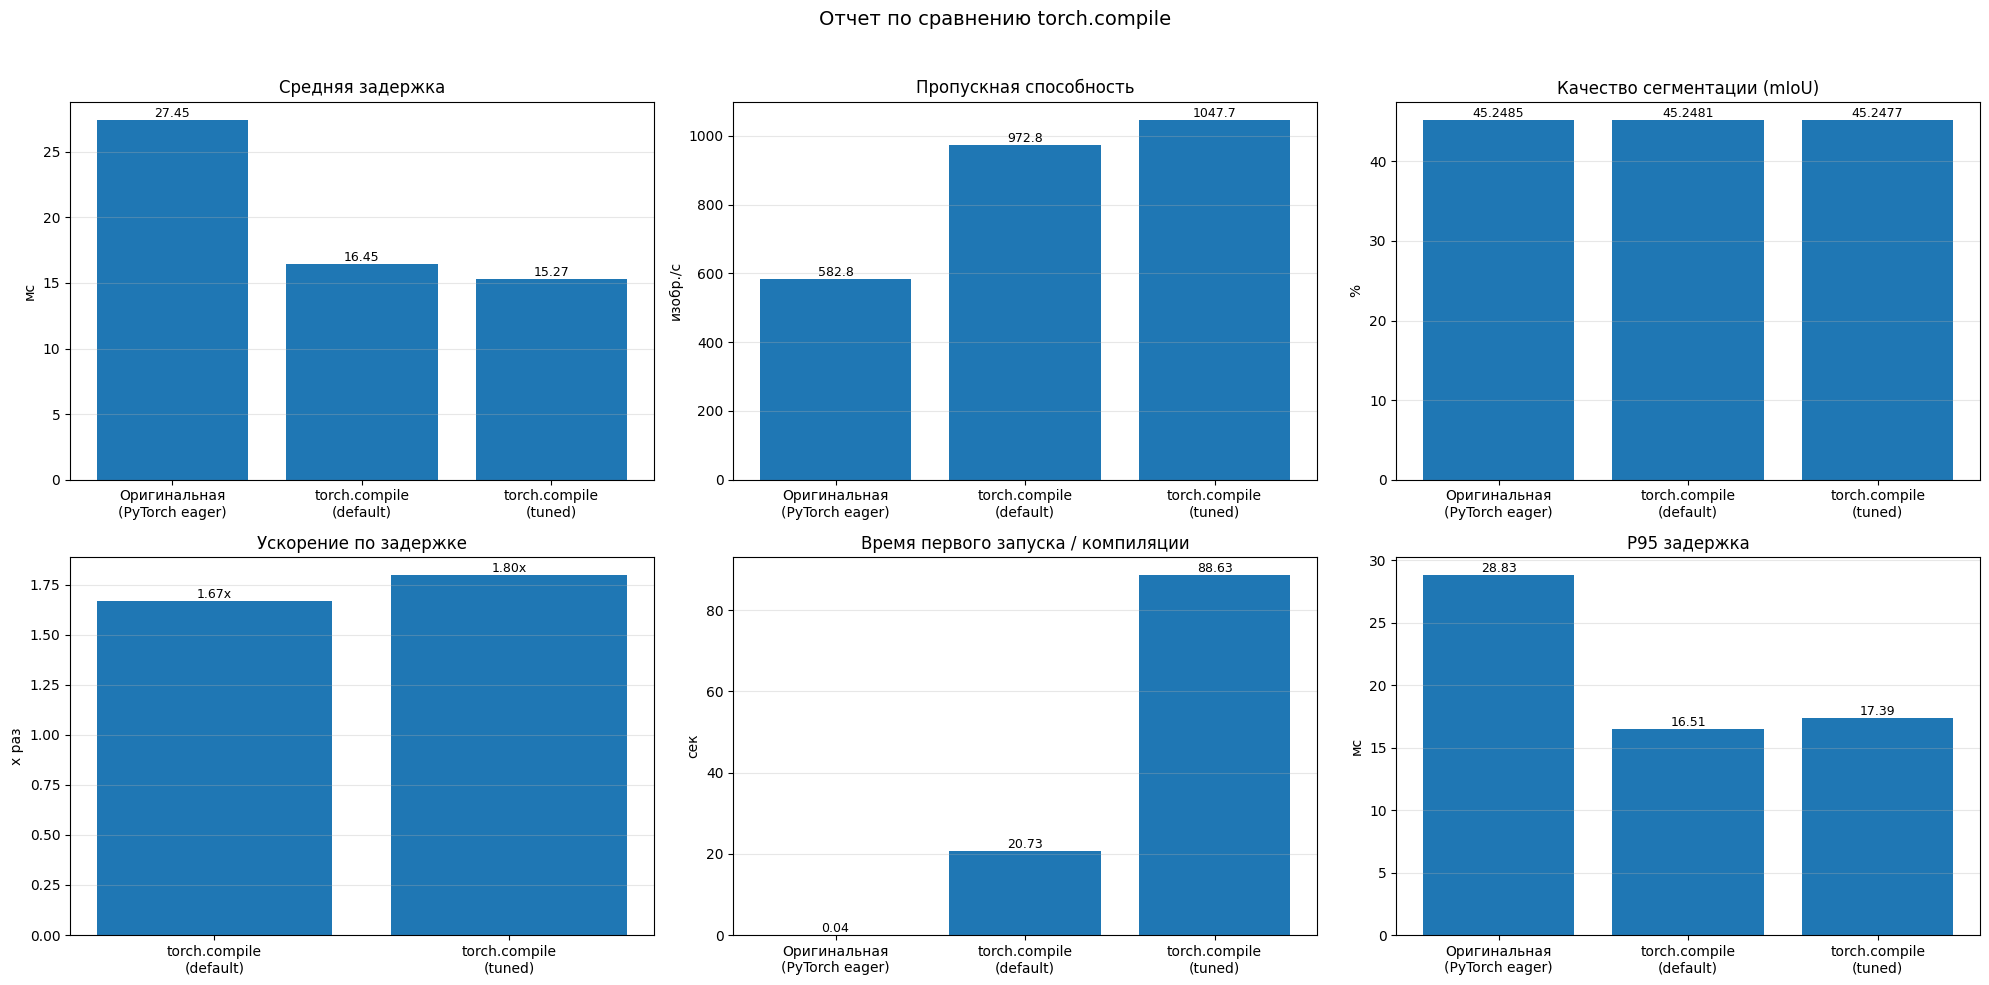


=== Краткий вывод ===
Лучшая средняя задержка: Компиляция torch с подобранными параметрами (torch.compile tuned) = 15.272 мс
Лучшая пропускная способность: Компиляция torch с подобранными параметрами (torch.compile tuned) = 1047.69 изображений/с
Лучшее качество по mIoU: Оригинальная модель (PyTorch eager) = 45.2485%


In [32]:
df_compile, err_compile = show_torch_compile_report(exp_compile)

# **TVM Experiment**

In [ ]:
import os
import time
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy

import torch
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

import tvm
from tvm import relax
from tvm.relax.frontend.torch import from_exported_program
from torch.export import export

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# =========================================================
# 1. CONFIG
# =========================================================
DEVICE_STR = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "/home/apotapenko/private_data/unet_efdl/weights/checkpoint_coco_fp16.pt"

IN_CHANNELS = 3
NUM_CLASSES = 81
INPUT_H, INPUT_W = IMAGE_SIZE
IGNORE_INDEX_EXP = IGNORE_INDEX

# BATCH_SIZE_BENCH = 1
BATCH_SIZE_BENCH = val_loader.batch_size
WARMUP = 5
ITERS = 20

# baseline у тебя fp16
USE_FP16_TORCH = (DEVICE_STR == "cuda")

# TVM tuning: сначала лучше False, чтобы все завелось
TVM_TUNE = False
TVM_TOTAL_TRIALS = 256
TVM_MAX_TRIALS_PER_TASK = 16
TVM_WORK_DIR = "tvm_tuning_logs"

## **2. BUILD MODEL**

In [ ]:
# def build_model_and_load_ckpt(path=MODEL_PATH):
#     model = smp.Unet(
#         encoder_name="resnet101",
#         encoder_weights=None,
#         in_channels=3,
#         classes=NUM_CLASSES,
#         activation=None,
#     )

#     baseline = model.half() # fp16
#     # baseline = model.bfloat16() # bf16

#     state = torch.load(CKPT_PATH, map_location="cpu")
#     baseline.load_state_dict(state, strict=True)

#     baseline = baseline.to(DEVICE).eval()
#     return baseline


def get_model_param_dtype(model):
    return next(model.parameters()).dtype


def cast_tensor_to_model_dtype(x, model):
    dtype = get_model_param_dtype(model)
    if dtype in (torch.float16, torch.bfloat16, torch.float32):
        return x.to(dtype=dtype)
    return x


def build_model_and_load_ckpt(path=CKPT_PATH, dtype=torch.float16, device=DEVICE_STR):
    model = smp.Unet(
        encoder_name="resnet101",
        encoder_weights=None,
        in_channels=3,
        classes=NUM_CLASSES,
        activation=None,
    )

    state = torch.load(path, map_location="cpu")
    if "model_state_dict" in state:
        state = state["model_state_dict"]
    elif "state_dict" in state:
        state = state["state_dict"]

    model.load_state_dict(state, strict=True)
    model = model.to(dtype=dtype).to(device).eval()

    print("Loaded model dtype:", next(model.parameters()).dtype)
    return model

## **3. TVM TARGET DETECTION**

In [ ]:
def get_tvm_target_and_device():
    try:
        if tvm.runtime.enabled("cuda") and tvm.cuda(0).exist:
            return tvm.target.Target("cuda"), tvm.cuda(0), "cuda"
    except Exception:
        pass

    return tvm.target.Target("llvm"), tvm.cpu(0), "llvm"


def tvm_to_numpy(x):
    """
    Совместимое извлечение numpy из результата TVM.
    """
    if hasattr(x, "numpy"):
        return x.numpy()
    if isinstance(x, (list, tuple)):
        x = x[0]
        if hasattr(x, "numpy"):
            return x.numpy()
    raise TypeError(f"Cannot convert TVM output to numpy, type={type(x)}")


def unwrap_tvm_output(out):
    """
    На случай, если VM возвращает контейнер / tuple / list.
    """
    if isinstance(out, (list, tuple)):
        return out[0]
    return out

def to_vm_arg(x):
    if isinstance(x, np.ndarray):
        return x
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    if hasattr(x, "numpy"):
        return x.numpy()
    return x

## **4. SAME BENCH INPUT FOR ALL METHODS**

In [ ]:
def get_benchmark_input(val_loader, batch_size=1, device="cpu"):
    images, _ = next(iter(val_loader))
    x = images[:batch_size].contiguous()
    return x.to(device)

## **5.  TORCH BENCHMARK**

In [ ]:
# @torch.no_grad()
# def benchmark_torch_model(model, x, device, warmup=WARMUP, iters=ITERS):
#     model.eval()
#     is_half_model = next(model.parameters()).dtype == torch.float16

#     x_run = x.half() if is_half_model else x.float()

#     for _ in range(warmup):
#         _ = model(x_run)
#     if device.startswith("cuda"):
#         torch.cuda.synchronize()

#     times = []
#     for _ in range(iters):
#         t0 = time.perf_counter()
#         _ = model(x_run)
#         if device.startswith("cuda"):
#             torch.cuda.synchronize()
#         t1 = time.perf_counter()
#         times.append((t1 - t0) * 1000.0)

#     times = np.array(times, dtype=np.float64)
#     mean_ms = float(times.mean())

#     return {
#         "latency_ms": mean_ms,
#         "p50_ms": float(np.percentile(times, 50)),
#         "p95_ms": float(np.percentile(times, 95)),
#         "throughput_img_s": float(x_run.shape[0] / (mean_ms / 1000.0)),
#     }

@torch.no_grad()
def benchmark_torch_model(model, x, device, warmup=WARMUP, iters=ITERS):
    model.eval()
    x_run = cast_tensor_to_model_dtype(x.to(device), model)

    for _ in range(warmup):
        _ = model(x_run)
    if device.startswith("cuda"):
        torch.cuda.synchronize()

    times = []
    for _ in range(iters):
        t0 = time.perf_counter()
        _ = model(x_run)
        if device.startswith("cuda"):
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000.0)

    times = np.array(times, dtype=np.float64)
    mean_ms = float(times.mean())

    return {
        "latency_ms": mean_ms,
        "p50_ms": float(np.percentile(times, 50)),
        "p95_ms": float(np.percentile(times, 95)),
        "throughput_img_s": float(x_run.shape[0] / (mean_ms / 1000.0)),
    }

## **6. METRIC — ТОЧНО КАК В BASELINE**

In [ ]:
# @torch.no_grad()
# def per_class_iou_torch_same_as_baseline(model, loader, device, num_classes, ignore_index=255):
#     model.eval()
#     confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64, device=device)

#     is_half_model = next(model.parameters()).dtype == torch.float16

#     for images, masks in loader:
#         images = images.to(device, non_blocking=True)
#         masks = masks.to(device, non_blocking=True)

#         if is_half_model:
#             images = images.half()

#         logits = model(images)
#         preds = logits.argmax(dim=1)

#         valid = masks != ignore_index
#         t = masks[valid]
#         p = preds[valid]
#         if t.numel() == 0:
#             continue

#         idx = t * num_classes + p
#         confmat += torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)

#     tp = confmat.diag()
#     fp = confmat.sum(0) - tp
#     fn = confmat.sum(1) - tp
#     denom = tp + fp + fn

#     iou = tp.float() / torch.clamp(denom.float(), min=1.0)
#     present = denom > 0
#     miou_present = iou[present].mean().item()

#     class_names = loader.dataset.class_names if hasattr(loader.dataset, "class_names") else [str(i) for i in range(num_classes)]

#     rows = []
#     for i in range(num_classes):
#         rows.append({
#             "class_id": i,
#             "class_name": class_names[i],
#             "iou": float(iou[i].item()),
#             "present_in_val": bool(present[i].item()),
#             "pixels_gt_or_pred": int(denom[i].item()),
#         })

#     return rows, miou_present

# @torch.no_grad()
# def per_class_iou_tvm_same_as_baseline(vm, params_vm, dev_tvm, loader, num_classes, ignore_index=255):
#     confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64)

#     for images, masks in loader:
#         x_np = images.detach().cpu().numpy().astype("float32")

#         out = vm["main"](x_np, *params_vm)
#         if isinstance(out, (list, tuple)):
#             out = out[0]
#         out_np = out.numpy() if hasattr(out, "numpy") else np.array(out)

#         logits = torch.from_numpy(out_np)
#         preds = logits.argmax(dim=1)
#         masks = masks.cpu()

#         valid = masks != ignore_index
#         t = masks[valid]
#         p = preds[valid]
#         if t.numel() == 0:
#             continue

#         idx = t * num_classes + p
#         confmat += torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)

#     tp = confmat.diag()
#     fp = confmat.sum(0) - tp
#     fn = confmat.sum(1) - tp
#     denom = tp + fp + fn

#     iou = tp.float() / torch.clamp(denom.float(), min=1.0)
#     present = denom > 0
#     miou_present = iou[present].mean().item()

#     class_names = loader.dataset.class_names
#     rows = []
#     for i in range(num_classes):
#         rows.append({
#             "class_id": i,
#             "class_name": class_names[i],
#             "iou": float(iou[i].item()),
#             "present_in_val": bool(present[i].item()),
#             "pixels_gt_or_pred": int(denom[i].item()),
#         })

#     return rows, miou_present


@torch.no_grad()
def per_class_iou_torch_same_as_baseline(model, loader, device, num_classes, ignore_index=255):
    model.eval()
    confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64, device=device)

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).long()

        images = cast_tensor_to_model_dtype(images, model)

        logits = model(images)
        preds = logits.argmax(dim=1)

        valid = masks != ignore_index
        t = masks[valid]
        p = preds[valid]
        if t.numel() == 0:
            continue

        idx = t * num_classes + p
        confmat += torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)

    tp = confmat.diag()
    fp = confmat.sum(0) - tp
    fn = confmat.sum(1) - tp
    denom = tp + fp + fn

    iou = tp.float() / torch.clamp(denom.float(), min=1.0)
    present = denom > 0
    miou_present = iou[present].mean().item()

    class_names = loader.dataset.class_names if hasattr(loader.dataset, "class_names") else [str(i) for i in range(num_classes)]

    rows = []
    for i in range(num_classes):
        rows.append({
            "class_id": i,
            "class_name": class_names[i],
            "iou": float(iou[i].item()),
            "present_in_val": bool(present[i].item()),
            "pixels_gt_or_pred": int(denom[i].item()),
        })

    return rows, miou_present

## **7. TVM EXPORT / BUILD**

In [ ]:
# =========================================================
# 7. TVM EXPORT / BUILD
# =========================================================
def _sync_tvm_device(dev_tvm):
    try:
        dev_tvm.sync()
    except Exception:
        pass


def _to_numpy_float32(x):
    if isinstance(x, np.ndarray):
        return x.astype(np.float32, copy=False)
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().float().numpy()
    if hasattr(x, "numpy"):
        return np.asarray(x.numpy(), dtype=np.float32)
    return np.asarray(x, dtype=np.float32)


def build_tvm_vm(pytorch_model, input_shape):
    model_for_export = deepcopy(pytorch_model).cpu().float().eval()

    print("TVM export model dtype:", next(model_for_export.parameters()).dtype)
    print("TVM export input shape:", input_shape)

    t0 = time.perf_counter()
    example = (torch.randn(*input_shape, dtype=torch.float32),)
    with torch.no_grad():
        exported = export(model_for_export, example)
        mod = from_exported_program(exported, keep_params_as_input=True)
    print(f"[TVM] torch.export + frontend: {time.perf_counter() - t0:.2f} sec")

    # веса отделяем
    mod, params = relax.frontend.detach_params(mod)

    # runtime input у main — первый аргумент, остальные это веса
    main_func = mod["main"]
    main_params = list(main_func.params)
    weight_vars = main_params[1:]

    assert len(weight_vars) == len(params["main"]), (
        f"Mismatch: weight_vars={len(weight_vars)}, detached_params={len(params['main'])}"
    )

    bind_dict = {
        var: _to_numpy_float32(val)
        for var, val in zip(weight_vars, params["main"])
    }

    # КЛЮЧЕВОЕ: привязываем веса один раз в IR
    mod = relax.transform.BindParams("main", bind_dict)(mod)

    target, dev_tvm, tvm_target_name = get_tvm_target_and_device()

    t1 = time.perf_counter()
    ex = tvm.compile(mod, target=target)
    print(f"[TVM] tvm.compile: {time.perf_counter() - t1:.2f} sec")

    vm = relax.VirtualMachine(ex, dev_tvm)
    return vm, dev_tvm, tvm_target_name


def run_tvm_model(vm, dev_tvm, x):
    x_np = _to_numpy_float32(x)
    vm.set_input("main", x_np)
    vm.invoke_stateful("main")
    out = vm.get_outputs("main")
    out = unwrap_tvm_output(out)
    return tvm_to_numpy(out)

## **8. TVM BENCHMARK**

In [ ]:
# =========================================================
# 8. TVM BENCHMARK
# =========================================================
def benchmark_tvm(vm, dev_tvm, x_bench, warmup=WARMUP, iters=ITERS):
    x_np = _to_numpy_float32(x_bench)

    for _ in range(warmup):
        vm.set_input("main", x_np)
        vm.invoke_stateful("main")
        _ = vm.get_outputs("main")
    _sync_tvm_device(dev_tvm)

    # Для benchmark bind'им уже готовый input
    vm.save_function("main", "main_saved", x_np)
    timer = vm.time_evaluator("main_saved", dev_tvm, number=1, repeat=iters)
    res = timer()

    times_ms = np.array(res.results, dtype=np.float64) * 1000.0
    mean_ms = float(times_ms.mean())

    return {
        "latency_ms": mean_ms,
        "p50_ms": float(np.percentile(times_ms, 50)),
        "p95_ms": float(np.percentile(times_ms, 95)),
        "throughput_img_s": float(x_bench.shape[0] / (mean_ms / 1000.0)),
    }

In [ ]:
# =========================================================
# 6b. TVM METRIC
# =========================================================
@torch.no_grad()
def per_class_iou_tvm_same_as_baseline(
    vm,
    dev_tvm,
    loader,
    num_classes,
    ignore_index=255,
):
    confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64)

    for images, masks in loader:
        masks = masks.cpu().long()

        out_np = run_tvm_model(vm, dev_tvm, images)

        logits = torch.from_numpy(out_np)
        preds = logits.argmax(dim=1)

        valid = masks != ignore_index
        t = masks[valid]
        p = preds[valid]
        if t.numel() == 0:
            continue

        idx = t * num_classes + p
        confmat += torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)

    tp = confmat.diag()
    fp = confmat.sum(0) - tp
    fn = confmat.sum(1) - tp
    denom = tp + fp + fn

    iou = tp.float() / torch.clamp(denom.float(), min=1.0)
    present = denom > 0
    miou_present = iou[present].mean().item()

    class_names = loader.dataset.class_names
    rows = []
    for i in range(num_classes):
        rows.append({
            "class_id": i,
            "class_name": class_names[i],
            "iou": float(iou[i].item()),
            "present_in_val": bool(present[i].item()),
            "pixels_gt_or_pred": int(denom[i].item()),
        })

    return rows, miou_present

## **9. TVM VISUALIZATION**

In [ ]:
def show_val_predictions_triplets_tvm(vm, params_vm, dev_tvm, val_ds, n_samples=4, seed=42, ignore_index=255):
    rng = random.Random(seed)
    idxs = [rng.randrange(len(val_ds)) for _ in range(n_samples)]

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    num_classes = val_ds.num_classes
    ignore_show_id = num_classes
    cmap, norm = _build_seg_cmap_with_ignore(num_classes)

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, idx in enumerate(idxs):
        image, true_mask = val_ds[idx]

        x_np = image.unsqueeze(0).detach().cpu().numpy().astype("float32")
        out = vm["main"](x_np, *params_vm)
        if isinstance(out, (list, tuple)):
            out = out[0]
        out_np = out.numpy() if hasattr(out, "numpy") else np.array(out)

        pred_mask = out_np.argmax(axis=1)[0]

        img_show = (image.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        true_show = true_mask.cpu().numpy().copy()
        true_show[true_show == ignore_index] = ignore_show_id

        axes[i, 0].imshow(img_show)
        axes[i, 0].set_title(f"image #{idx}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(true_show, cmap=cmap, norm=norm, interpolation="nearest")
        axes[i, 1].set_title("true_mask_val")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_mask, cmap=cmap, norm=norm, interpolation="nearest")
        axes[i, 2].set_title("pred_mask_tvm")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

## **10. MAIN FUNC**

In [ ]:
# =========================================================
# 10. MAIN FUNC
# =========================================================
def main_tvm_experiment(val_loader, model_loaded=None):
    # Берём уже загруженную до TVM experiment модель:
    # она может быть либо fp16, либо bf16.
    if model_loaded is None:
        if "baseline" in globals():
            model_loaded = baseline
        else:
            model_loaded = build_model_and_load_ckpt()

    model_native = deepcopy(model_loaded).to(DEVICE_STR).eval()
    native_dtype = get_model_param_dtype(model_native)

    print("Native model dtype:", native_dtype)

    x_bench = get_benchmark_input(val_loader, batch_size=BATCH_SIZE_BENCH, device=DEVICE_STR)

    # отдельная shape для TVM-metric path
    eval_images, _ = next(iter(val_loader))
    eval_batch_shape = tuple(eval_images.shape)

    results = {}

    # A. PyTorch native baseline (ключ оставляем прежним, чтобы show_benchmark_report не менять)
    results["pytorch_fp16_baseline"] = benchmark_torch_model(model_native, x_bench, DEVICE_STR)
    torch_rows, torch_miou = per_class_iou_torch_same_as_baseline(
        model_native, val_loader, DEVICE_STR, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX_EXP
    )
    results["pytorch_fp16_baseline"]["miou_present"] = float(torch_miou)
    results["pytorch_fp16_baseline"]["dtype"] = str(native_dtype).replace("torch.", "")

    # B. torch.compile default
    compiled_default = torch.compile(
        deepcopy(model_native),
        backend="inductor",
        mode="default",
        dynamic=False,
    )

    # C. torch.compile max-autotune
    compiled_max = torch.compile(
        deepcopy(model_native),
        backend="inductor",
        mode="max-autotune",
        dynamic=False,
    )

    # D. TVM
    tvm_rows = None
    try:
        vm, dev_tvm, tvm_target_name = build_tvm_vm(
            model_native,
            input_shape=tuple(x_bench.shape),
        )

        results["tvm_relax_tir"] = benchmark_tvm(vm, dev_tvm, x_bench)

        tvm_rows, tvm_miou = per_class_iou_tvm_same_as_baseline(
            vm,
            dev_tvm,
            val_loader,
            num_classes=NUM_CLASSES,
            ignore_index=IGNORE_INDEX_EXP,
        )
        results["tvm_relax_tir"]["miou_present"] = float(tvm_miou)
        results["tvm_relax_tir"]["target"] = tvm_target_name
        results["tvm_relax_tir"]["dtype"] = f"float32_export_from_{str(native_dtype).replace('torch.', '')}"

    except Exception as e:
        results["tvm_relax_tir"] = {"error": str(e)}

    print(json.dumps(results, indent=2, ensure_ascii=False))
    return {
        "results": results,
        "torch_rows": torch_rows,
        "tvm_rows": tvm_rows,
    }

In [ ]:
# exp_out = main_tvm_experiment(val_loader)

## **11. Vizualization**

In [ ]:
def show_benchmark_report(exp_out, title="Отчет по сравнению методов инференса"):
    """
    Красивый отчет по результатам benchmark.

    Поддерживает оба формата входа:
    1) exp_out = {
           "results": {...},
           "torch_rows": ...,
           "tvm_rows": ...
       }
    2) exp_out = {
           "pytorch_fp16_baseline": {...},
           "torch_compile_default": {...},
           ...
       }

    Возвращает:
        df, err_df
    """

    # --------------------------------------------------
    # 1. Достаём results
    # --------------------------------------------------
    if isinstance(exp_out, dict) and "results" in exp_out:
        results = exp_out["results"]
    else:
        results = exp_out

    if not isinstance(results, dict):
        raise ValueError("exp_out должен быть словарём или словарём с ключом 'results'")

    # --------------------------------------------------
    # 2. Собираем строки и ошибки
    # --------------------------------------------------
    rows = []
    errors = []

    for method, vals in results.items():
        if not isinstance(vals, dict):
            errors.append({"method": method, "error": f"Unexpected value type: {type(vals)}"})
            continue

        if "error" in vals:
            errors.append({"method": method, "error": vals["error"]})
            continue

        required_keys = ["latency_ms", "p50_ms", "p95_ms", "throughput_img_s", "miou_present"]
        missing = [k for k in required_keys if k not in vals]
        if missing:
            errors.append({"method": method, "error": f"Missing keys: {missing}"})
            continue

        rows.append({
            "method": method,
            "latency_ms": float(vals["latency_ms"]),
            "p50_ms": float(vals["p50_ms"]),
            "p95_ms": float(vals["p95_ms"]),
            "throughput_img_s": float(vals["throughput_img_s"]),
            "miou_present": float(vals["miou_present"]),
            "miou_percent": float(vals["miou_present"]) * 100.0,
        })

    df = pd.DataFrame(rows)
    err_df = pd.DataFrame(errors)

    if df.empty:
        print("Нет валидных результатов для отображения.")
        if not err_df.empty:
            print("\nОшибки:")
            display(err_df)
        return df, err_df

    # --------------------------------------------------
    # 3. Порядок методов и красивые названия
    # --------------------------------------------------
    method_order = [
        "pytorch_fp16_baseline",
        "torch_compile_default",
        "torch_compile_max_autotune",
        "tvm_relax_tir",
    ]

    # для графиков
    pretty_names_ru = {
        "pytorch_fp16_baseline": "PyTorch fp16\n(базовый)",
        "torch_compile_default": "torch.compile\n(default)",
        "torch_compile_max_autotune": "torch.compile\n(max-autotune)",
        "tvm_relax_tir": "TVM\n(Relax/TIR)",
    }

    # для таблицы: русское название + английское в скобках
    pretty_names_table = {
        "pytorch_fp16_baseline": "PyTorch fp16 (baseline)",
        "torch_compile_default": "Компиляция torch (torch.compile default)",
        "torch_compile_max_autotune": "Компиляция torch с автонастройкой (torch.compile max-autotune)",
        "tvm_relax_tir": "TVM Relax/TIR (TVM Relax/TIR)",
    }

    extra_methods = [m for m in df["method"].tolist() if m not in method_order]
    full_order = method_order + [m for m in extra_methods if m not in method_order]

    df["method"] = pd.Categorical(df["method"], categories=full_order, ordered=True)
    df = df.sort_values("method").reset_index(drop=True)

    df["pretty_method"] = df["method"].map(lambda x: pretty_names_ru.get(x, str(x)))
    df["pretty_method_table"] = df["method"].map(lambda x: pretty_names_table.get(x, str(x)))

    # --------------------------------------------------
    # 4. Speedup vs baseline
    # --------------------------------------------------
    baseline_df = df[df["method"] == "pytorch_fp16_baseline"]
    if baseline_df.empty:
        raise ValueError("В results нет 'pytorch_fp16_baseline', невозможно посчитать ускорение")

    baseline = baseline_df.iloc[0]

    df["latency_speedup_vs_baseline"] = baseline["latency_ms"] / df["latency_ms"]
    df["throughput_gain_vs_baseline"] = df["throughput_img_s"] / baseline["throughput_img_s"]
    df["miou_delta_abs"] = df["miou_present"] - baseline["miou_present"]
    df["miou_delta_percent_points"] = df["miou_percent"] - baseline["miou_percent"]

    # --------------------------------------------------
    # 5. Таблица
    # --------------------------------------------------
    table_df = df[[
        "pretty_method_table",
        "latency_ms",
        "p50_ms",
        "p95_ms",
        "throughput_img_s",
        "miou_percent",
        "latency_speedup_vs_baseline",
        "throughput_gain_vs_baseline",
        "miou_delta_abs",
    ]].copy()

    table_df = table_df.rename(columns={
        "pretty_method_table": "Метод (Method)",
        "latency_ms": "Средняя задержка, мс (Latency, ms)",
        "p50_ms": "Медианная задержка P50, мс (P50, ms)",
        "p95_ms": "Задержка P95, мс (P95, ms)",
        "throughput_img_s": "Пропускная способность, изображений/с (Throughput, img/s)",
        "miou_percent": "Средний IoU, % (mIoU, %)",
        "latency_speedup_vs_baseline": "Ускорение по задержке относительно baseline (Speedup vs baseline)",
        "throughput_gain_vs_baseline": "Прирост throughput относительно baseline (Throughput gain vs baseline)",
        "miou_delta_abs": "Изменение mIoU (ΔmIoU)",
    })

    print("=== Итоговая таблица ===")
    display(table_df)

    if not err_df.empty:
        err_df = err_df.rename(columns={
            "method": "Метод",
            "error": "Ошибка",
        })
        print("\n=== Ошибки ===")
        display(err_df)

    # --------------------------------------------------
    # 6. Графики: 2x2
    # --------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(title, fontsize=14)

    # 6.1 Latency
    ax = axes[0, 0]
    bars = ax.bar(df["pretty_method"], df["latency_ms"])
    ax.set_title("Сравнение средней задержки")
    ax.set_ylabel("мс")
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, df["latency_ms"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    # 6.2 Throughput
    ax = axes[0, 1]
    bars = ax.bar(df["pretty_method"], df["throughput_img_s"])
    ax.set_title("Сравнение пропускной способности")
    ax.set_ylabel("изображений/с")
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, df["throughput_img_s"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    # 6.3 mIoU
    ax = axes[1, 0]
    bars = ax.bar(df["pretty_method"], df["miou_percent"])
    ax.set_title("Сравнение качества сегментации (mIoU)")
    ax.set_ylabel("%")
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, df["miou_percent"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    # 6.4 Speedup
    ax = axes[1, 1]
    df_speed = df[df["method"] != "pytorch_fp16_baseline"].copy()
    if not df_speed.empty:
        bars = ax.bar(df_speed["pretty_method"], df_speed["latency_speedup_vs_baseline"])
        ax.set_title("Ускорение по задержке относительно baseline")
        ax.set_ylabel("раз")
        ax.grid(axis="y", alpha=0.3)
        for bar, val in zip(bars, df_speed["latency_speedup_vs_baseline"]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{val:.2f}x",
                ha="center",
                va="bottom",
                fontsize=9,
            )
    else:
        ax.text(0.5, 0.5, "Нет методов для сравнения", ha="center", va="center")
        ax.set_axis_off()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # --------------------------------------------------
    # 7. Краткий вывод
    # --------------------------------------------------
    best_latency_row = df.loc[df["latency_ms"].idxmin()]
    best_throughput_row = df.loc[df["throughput_img_s"].idxmax()]
    best_miou_row = df.loc[df["miou_present"].idxmax()]

    print("\n=== Краткий вывод ===")
    print(
        f"Лучшая средняя задержка: {best_latency_row['pretty_method_table']} = "
        f"{best_latency_row['latency_ms']:.3f} мс"
    )
    print(
        f"Лучшая пропускная способность: {best_throughput_row['pretty_method_table']} = "
        f"{best_throughput_row['throughput_img_s']:.2f} изображений/с"
    )
    print(
        f"Лучшее качество по mIoU: {best_miou_row['pretty_method_table']} = "
        f"{best_miou_row['miou_percent']:.4f}%"
    )

    print("\nСравнение с baseline:")
    for _, row in df[df["method"] != "pytorch_fp16_baseline"].iterrows():
        print(
            f"{row['pretty_method_table']}: "
            f"ускорение={row['latency_speedup_vs_baseline']:.2f}x, "
            f"прирост throughput={row['throughput_gain_vs_baseline']:.2f}x, "
            f"ΔmIoU={row['miou_delta_abs']:.8f}"
        )

    return df, err_df

In [ ]:
# exp_out = main_tvm_experiment(val_loader)

Native model dtype: torch.float16
TVM export model dtype: torch.float32
TVM export input shape: (16, 3, 384, 384)


/home/apotapenko/miniconda3/envs/tvm-env/lib/python3.10/copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[TVM] torch.export + frontend: 6.23 sec
[TVM] tvm.compile: 5.91 sec


In [ ]:
# df_report, err_report = show_benchmark_report(exp_out)